In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
sns.set_style("whitegrid")

In [2]:
# Upload file from your computer
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
# Load the Titanic dataset
df = pd.read_csv("train.csv")

# Show first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Summary statistics of numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
# Check how many missing values exist in each column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
# Fill missing Age values with the mean age
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [10]:
# Fill missing Embarked values with the most frequent value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df.drop('Cabin', axis=1, inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [27]:
# Convert Sex column into numeric values
# male = 0, female = 1

df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# Calculate overall survival rate
df['Survived'].mean()

# Group data by gender and calculate survival rate
df.groupby('Sex')['Survived'].mean()

#Survival rate by passenger class
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


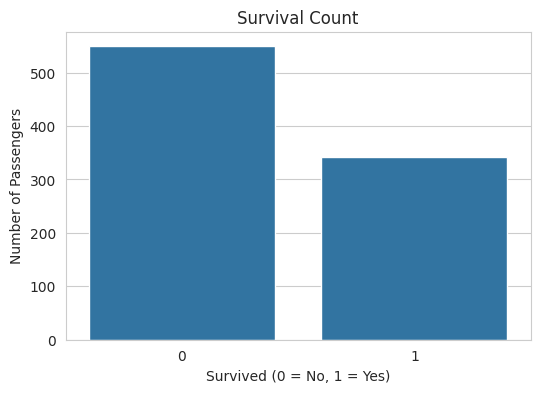

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()



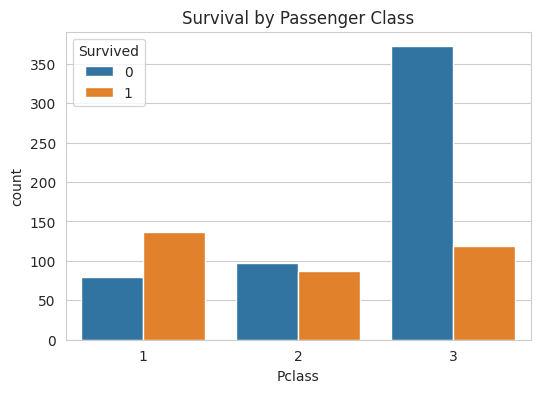

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")

plt.show()

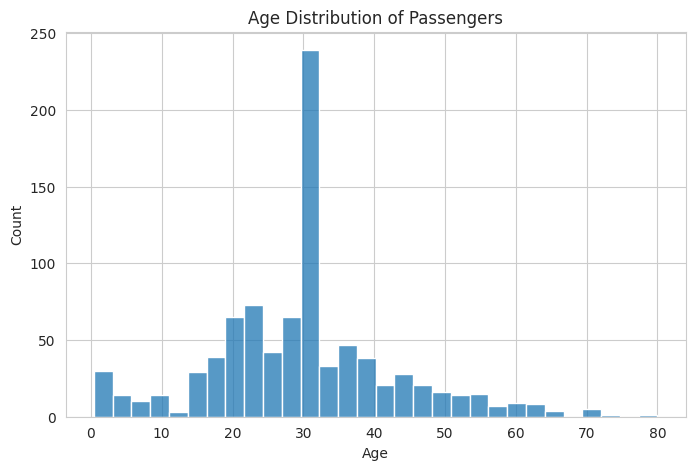

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")

plt.show()

In [30]:
# Reload dataset
df = pd.read_csv("train.csv")

# Convert Sex column correctly
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

df['Sex'].value_counts()

,count
Sex,
0,577
1,314


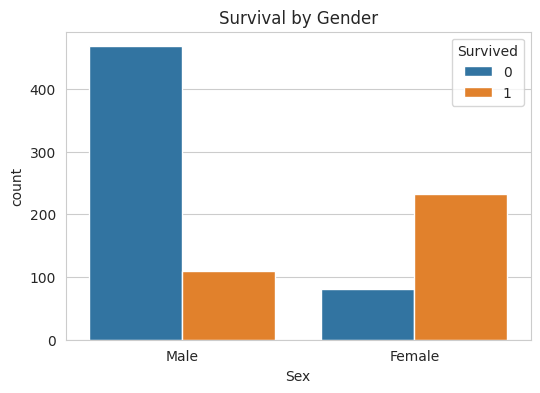

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.xticks([0,1], ["Male","Female"])

plt.title("Survival by Gender")
plt.show()

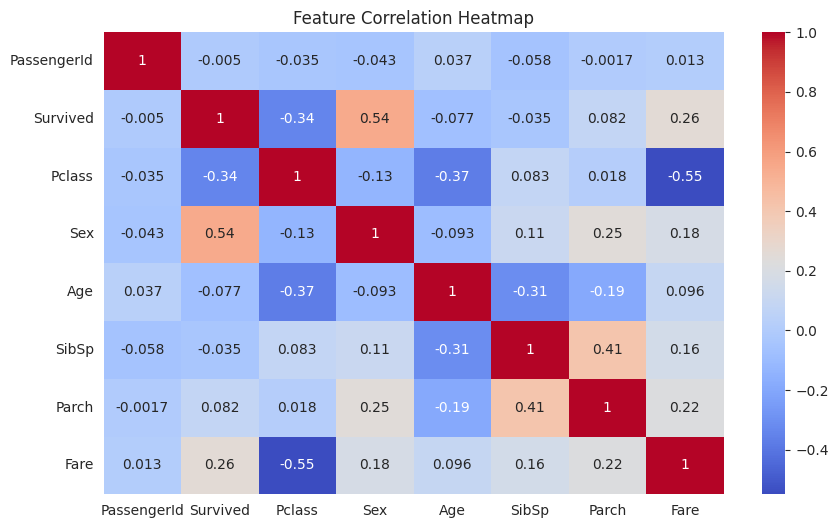

In [34]:
plt.figure(figsize=(10,6))

# Correlation only for numeric columns
corr = df.select_dtypes(include=['number']).corr()

# Create heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()